# Step 2: Outcome Modelling

## Libaries

In [2]:
from pathlib import Path
from pickle import dump, load
from pprint import pprint

import modules as geoint
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

/Users/rrwen/Desktop/geointerv-paper/tmp/venv/lib/python3.9/site-packages/geopandas/_compat.py:123: UserWarning: The Shapely GEOS version (3.11.1-CAPI-1.17.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(
/Users/rrwen/Desktop/geointerv-paper/src/case-study/modules/data.py:1: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 

## Folders

Create folders for storing models and related data.

In [3]:
# Set folder for data and models
data_folder = '../../tmp/data'
model_folder = '../../tmp/models'

# Create folders for model data
Path(data_folder).mkdir(parents=True, exist_ok=True)
Path(model_folder).mkdir(parents=True, exist_ok=True)

## Train AutoML Models

In [4]:
models = {}
geodata = {}
for size in [10, 40, 80]:
    
    # Load data
    print(f'Processing geogrid_to_{size}...')
    xraw = gpd.read_file(f'{data_folder}/geogrid_to_{size}.geojson')
    x = pd.DataFrame(xraw.drop(columns='geometry'))
    ycol = 'collisions_count'
    geodata[f'geogrid_to_{size}'] = xraw
    
    # Columns to remove from input data
    startswith = ['collisions']
    
    # Drop columns except target col
    drop = [c for c in x.columns if any(c.startswith(s) for s in startswith) and c != ycol]
    x = x.drop(columns=drop)
    
    # Train autosklearn model
    ask_file = f'{model_folder}/autosklearn_{size}.pkl'
    if Path(ask_file).is_file():
        print(f'Model for autosklearn_{size} exists - skipping training...')
        with open(ask_file, 'rb') as f:
            ask = load(f)
    else:
        print(f'Training model for autosklearn_{size}...')
        ask = geoint.models.AutoMLModel('AutoSklearnRegressor')
        ask.fit(x=x, y=ycol)
        ask.predict()
        print(f'Saving model for autosklearn_{size}...')
        with open(ask_file, 'wb') as f:
            dump(ask, f)
    
    # Train tpot model
    tpt_file = f'{model_folder}/tpot_{size}.pkl'
    if Path(tpt_file).is_file():
        print(f'Model for tpot_{size} exists - skipping training...')
        tpt = geoint.models.AutoMLModel('TPOTRegressor')
        with open(tpt_file, 'rb') as f:
            tpt.model = load(f)
        tpt.last_x = x.drop(columns=ycol).select_dtypes('number').fillna(0)
        tpt.last_y = x[ycol]
        tpt.predict()
    else:
        print(f'Training model for tpot_{size}...')
        tpt = geoint.models.AutoMLModel('TPOTRegressor')
        tpt.fit(x=x, y=ycol) # if you get a runtime error, run this line in a separate cell, stop it, then try this code block again
        tpt.predict()
        print(f'Saving model for tpot_{size}...')
        with open(tpt_file, 'wb') as f:
            dump(tpt.model.fitted_pipeline_, f)
    
    # Store models
    models[f'autosklearn_{size}'] = ask
    models[f'tpot_{size}'] = tpt

print('Done!')

Processing geogrid_to_10...
Model for autosklearn_10 exists - skipping training...
Model for tpot_10 exists - skipping training...
Processing geogrid_to_40...
Model for autosklearn_40 exists - skipping training...
Model for tpot_40 exists - skipping training...
Processing geogrid_to_80...
Model for autosklearn_80 exists - skipping training...
Model for tpot_80 exists - skipping training...
Done!


Preview models:

In [5]:
pprint(models)

{'autosklearn_10': <modules.models.AutoMLModel object at 0x1112cddf0>,
 'autosklearn_40': <modules.models.AutoMLModel object at 0x1689c0880>,
 'autosklearn_80': <modules.models.AutoMLModel object at 0x168aa3760>,
 'tpot_10': <modules.models.AutoMLModel object at 0x169449250>,
 'tpot_40': <modules.models.AutoMLModel object at 0x168aa1910>,
 'tpot_80': <modules.models.AutoMLModel object at 0x168a9b670>}


## Calculate Model Scores

In [6]:
# Calc scores
scores = {'model': [], 'metric': [], 'score': []}
for name, m in models.items():
    
    # Default score
    scores['model'].append(name)
    scores['score'].append(m.score())
    scores['metric'].append(m.last_metric)
    
    # MAE score
    scores['model'].append(name)
    scores['score'].append(m.score(metric='mean_absolute_error'))
    scores['metric'].append('mean_absolute_error')
scores = pd.DataFrame(scores)

# Save scores
scores.to_csv(f'{model_folder}/scores.csv', index=False)

<AxesSubplot:title={'center':'Mean Absolute Error (MAE)'}, xlabel='Model'>

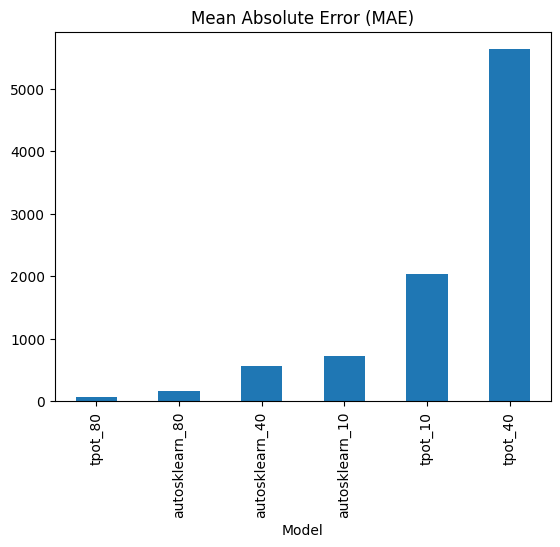

In [7]:
# Plot scores
scores[scores.metric == 'mean_absolute_error']\
    .sort_values(by='score')\
    .plot.bar(
        x='model',
        y='score',
        xlabel='Model',
        legend=False,
        title='Mean Absolute Error (MAE)'
    )

## Calculate Variable Importances

In [8]:
# Calc importances
importances_file = f'{model_folder}/importances.csv'
if Path(importances_file).is_file():

    # Skip calc and load importances
    print(f'Variable importances file exists - loading importances...')
    importances = pd.read_csv(importances_file)
    print('Done!')

else:
    
    # Calc importances for each model
    importances = []
    for name, m in models.items():
        print(f'Processing {name}...')
        imp_file = f'{model_folder}/{name}_importance.pkl'
        
        # Calculate var importances
        if Path(imp_file).is_file():
            print(f'Variable importances for {name} exists - loading...')
            with open(imp_file, 'rb') as f:
                imp = load(f) 
        else:
            print(f'Calculating variable importances for {name}...')
            imp = m.importance()
            with open(imp_file, 'wb') as f:
                dump(imp, f)
        
        # Store var importances
        imp['model'] = name
        importances.append(imp)

    # Combine importances
    importances = pd.concat(importances).sort_values(by='importance_mean', ascending=False)
    print('Done!')

    # Save importances
    importances.to_csv(importances_file, index=False)
    

Processing autosklearn_10...
Calculating variable importances for autosklearn_10...
Processing tpot_10...
Calculating variable importances for tpot_10...
Processing autosklearn_40...
Calculating variable importances for autosklearn_40...
Processing tpot_40...
Calculating variable importances for tpot_40...
Processing autosklearn_80...
Calculating variable importances for autosklearn_80...
Processing tpot_80...
Calculating variable importances for tpot_80...
Done!


<AxesSubplot:title={'center':'Variable Importance'}, xlabel='Variable', ylabel='variable'>

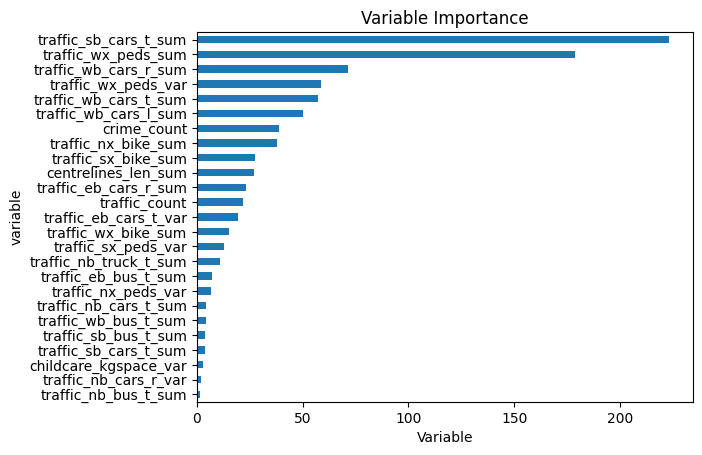

In [25]:
# Plot importances
importances\
    .nlargest(25, 'importance_mean')\
    .sort_values(by='importance_mean')\
    .plot.barh(x='variable', y='importance_mean', xlabel='Variable', title='Variable Importance', legend=False)

<AxesSubplot:title={'center':'Variable Importance (Non-traffic)'}, xlabel='Variable', ylabel='variable'>

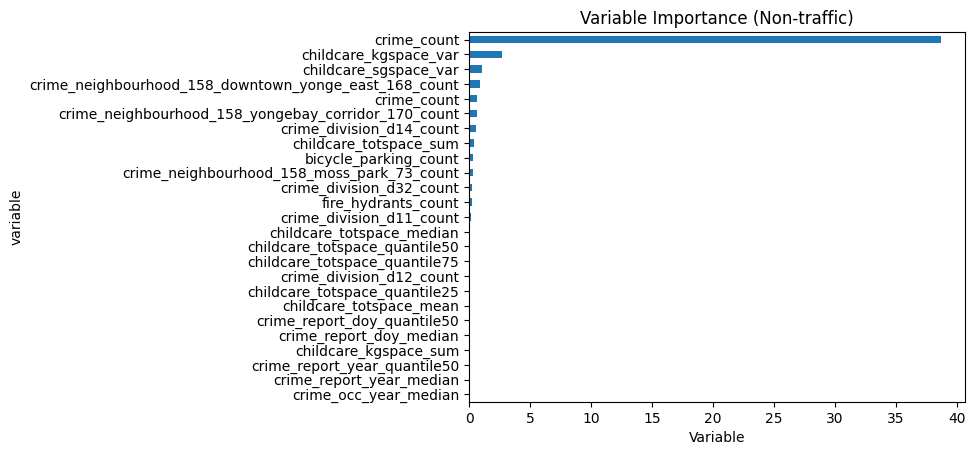

In [28]:
importances[~importances.variable.str.startswith(('traffic', 'centrelines'))]\
    .nlargest(25, 'importance_mean')\
    .sort_values(by='importance_mean')\
    .plot.barh(x='variable', y='importance_mean', xlabel='Variable', title='Variable Importance (Non-traffic)', legend=False)